# Validación Empírica de la Teoría AIQ con Datos de Citación Temporal

## Marco teórico

Sea $Q = (Q_0, Q_1, s, t)$ un quiver que representa un grafo de citación: los vértices $Q_0$ son artículos y cada flecha $\alpha \in Q_1$ va del artículo citante al citado ($s(\alpha) \to t(\alpha)$). El autómata de impacto (AIQ) asigna a cada vértice un estado en $\{S, R, O\}$ (Susceptible, Relevante, Obsoleto) y evoluciona según reglas SIR ponderadas por la **tasa de impacto**:

$$i^t(c) = \frac{\beta}{\alpha} \sum_{g=1}^{g_{\max}} \frac{\sigma_{g,K}^t(c)}{\Delta_g(c)} \cdot P(g)$$

donde $\sigma_{g,K}^t(c)$ cuenta los vecinos en estado $K$ en la capa $g$ del Sistema Fundamental de Vecindades (SFV), $\Delta_g(c) = |N_g(c)|$ es el tamaño de la capa, y $P(g)$ es una función de peso decreciente.

### Objetivo

Comparar las predicciones cualitativas del modelo AIQ con la dinámica empírica de citaciones usando el dataset **cit-HepPh** (SNAP), que contiene fechas exactas de publicación.

### Predicciones a validar

| # | Predicción | Formulación |
|---|---|---|
| 1 | **Trampas topológicas** | Vértices con menor conectividad entrante pierden relevancia más rápido |
| 2 | **Decaimiento de relevancia** | La fracción de una cohorte en estado $R$ decrece de forma análoga a la curva empírica de citación |
| 3 | **Tasa $\to$ citaciones futuras** | $i^t(c)$ mayor $\implies$ más citaciones futuras reales |
| 4 | **Localidad del SFV** | La influencia de citación está concentrada entre artículos topológicamente cercanos |
| 5 | **Timing de obsolescencia** | El paso AIQ donde la cohorte pierde mayoría $R$ correlaciona con el lifetime empírico |

### Convención

Cada prueba estadística se reporta con: hipótesis nula $H_0$, estadístico de prueba, $p$-valor, y tamaño del efecto cuando sea posible. **Las interpretaciones se basan exclusivamente en los resultados numéricos obtenidos.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats as sp_stats

from aiq import datasets, validation, visualization, AIQ
from aiq.impact import FundamentalNeighborhoodSystem

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)

P = lambda g: 1.0 / g if g >= 1 else 1.0
print("Paquete AIQ cargado.")

Paquete AIQ cargado.


---
## 1. Dataset cit-HepPh

El dataset proviene de SNAP (Stanford Network Analysis Project) y contiene citaciones entre artículos del archivo hep-ph (Fenomenología de Altas Energías) de arXiv.

In [14]:
Q_full, meta_full = datasets.load_hepph()

In [17]:
Q_full

Quiver(|Q_0|=21550, |Q_1|=201300, vertices=['9203201', '9203202', '9203203', '9203206', '9203207', '9203208', '9203210', '9203211', '9203212', '9203213', '9203215', '9203216', '9203217', '9203219', '9203220', '9203221', '9203222', '9203223', '9203224', '9203225', '9204201', '9204202', '9204203', '9204204', '9204205', '9204206', '9204207', '9204208', '9204210', '9204211', '9204212', '9204213', '9204214', '9204215', '9204216', '9204217', '9204219', '9204220', '9204222', '9204223', '9204224', '9204225', '9204226', '9204227', '9204228', '9204229', '9204231', '9204232', '9204234', '9204235', '9204236', '9204237', '9204238', '9204239', '9205201', '9205202', '9205203', '9205204', '9205205', '9205207', '9205208', '9205209', '9205210', '9205212', '9205213', '9205214', '9205215', '9205217', '9205218', '9205220', '9205221', '9205222', '9205224', '9205226', '9205227', '9205228', '9205229', '9205230', '9205231', '9205232', '9205233', '9205234', '9205235', '9205236', '9205237', '9205238', '9205240',

Grafo de citación Q = (Q₀, Q₁):
  |Q₀| = 21,550 vértices (artículos)
  |Q₁| = 201,300 flechas (citaciones)
  Densidad: 0.000433
  Rango temporal: 1992–1999
  Ejemplo: ('9203201', {'date': datetime.date(1992, 2, 24), 'year': 1992})


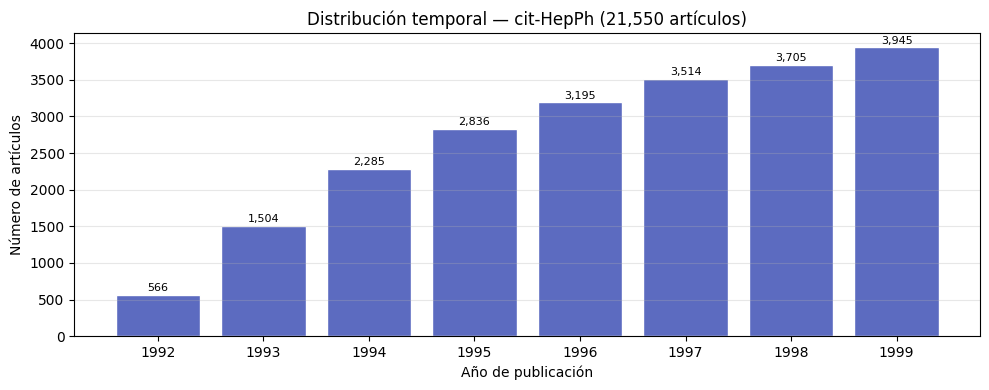

In [2]:
Q_full, meta_full = datasets.load_hepph()

print(f"Grafo de citación Q = (Q₀, Q₁):")
print(f"  |Q₀| = {Q_full.n_vertices:,} vértices (artículos)")
print(f"  |Q₁| = {Q_full.n_arrows:,} flechas (citaciones)")
density = Q_full.n_arrows / (Q_full.n_vertices * (Q_full.n_vertices - 1))
print(f"  Densidad: {density:.6f}")

years = [m['year'] for m in meta_full.values()]
print(f"  Rango temporal: {min(years)}–{max(years)}")
print(f"  Ejemplo: {list(meta_full.items())[0]}")

# Distribución por año
year_counts = pd.Series(years).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(year_counts.index, year_counts.values,
              color='#5C6BC0', edgecolor='white')
ax.set_xlabel('Año de publicación')
ax.set_ylabel('Número de artículos')
ax.set_title(f'Distribución temporal — cit-HepPh ({Q_full.n_vertices:,} artículos)')
for yr, cnt in year_counts.items():
    ax.text(yr, cnt + 50, f'{cnt:,}', ha='center', fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Diagnóstico de calidad de datos

Antes de cualquier análisis, verificamos la consistencia temporal: ¿existen citaciones con edad negativa (artículo citante publicado *antes* que el citado)?

Total de citaciones con fechas válidas: 201,300

Estadísticas de edad de citación (años):
count    201300.000000
mean          1.884009
std           1.581769
min          -7.000000
25%           1.000000
50%           2.000000
75%           3.000000
max           7.000000

Citaciones con edad negativa: 478 (0.2%)
  Causa probable: las fechas corresponden a la primera aparición en arXiv.
  Un artículo puede citar un preprint que aparece después de su propia
  fecha de envío (revisiones, versiones, retrasos editoriales).
  Estas citaciones se incluyen pero se señalan.


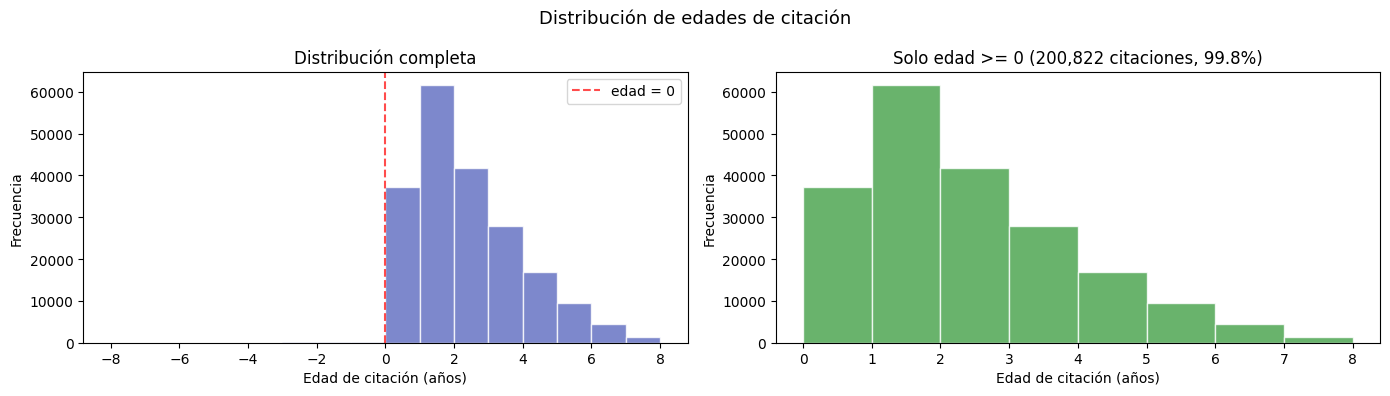

In [3]:
ages_df = validation.compute_citation_ages(Q_full, meta_full)

print(f"Total de citaciones con fechas válidas: {len(ages_df):,}")
print(f"\nEstadísticas de edad de citación (años):")
print(ages_df['citation_age_years'].describe().to_string())

neg_ages = ages_df[ages_df['citation_age_years'] < 0]
n_neg = len(neg_ages)
pct_neg = 100 * n_neg / len(ages_df)
print(f"\nCitaciones con edad negativa: {n_neg:,} ({pct_neg:.1f}%)")
print("  Causa probable: las fechas corresponden a la primera aparición en arXiv.")
print("  Un artículo puede citar un preprint que aparece después de su propia")
print("  fecha de envío (revisiones, versiones, retrasos editoriales).")
print("  Estas citaciones se incluyen pero se señalan.")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(ages_df['citation_age_years'], bins=range(-8, 9),
             color='#5C6BC0', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.7, label='edad = 0')
axes[0].set_xlabel('Edad de citación (años)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución completa')
axes[0].legend()

pos_ages = ages_df[ages_df['citation_age_years'] >= 0]
axes[1].hist(pos_ages['citation_age_years'], bins=range(0, 9),
             color='#43A047', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Edad de citación (años)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Solo edad >= 0 ({len(pos_ages):,} citaciones, {100*len(pos_ages)/len(ages_df):.1f}%)')

plt.suptitle('Distribución de edades de citación', fontsize=13)
plt.tight_layout()
plt.show()

---
## 2. Estadísticas descriptivas del grafo

Caracterización topológica relevante para la teoría AIQ: distribución de grados, vértices fuente ($\text{in-deg} = 0$), y vida útil de citación.

Estadísticas de vida útil de citación (años):
count    21550.00000
mean         1.77058
std          1.86579
min         -2.00000
25%          0.00000
50%          1.00000
75%          3.00000
max          7.00000

Artículos nunca citados: 4,550 (21.1%)
Vértices fuente (in-degree = 0): 4,550
  Coinciden con 'nunca citados': SÍ
  (Definitorio: in-degree = 0 <=> cero citaciones recibidas.)


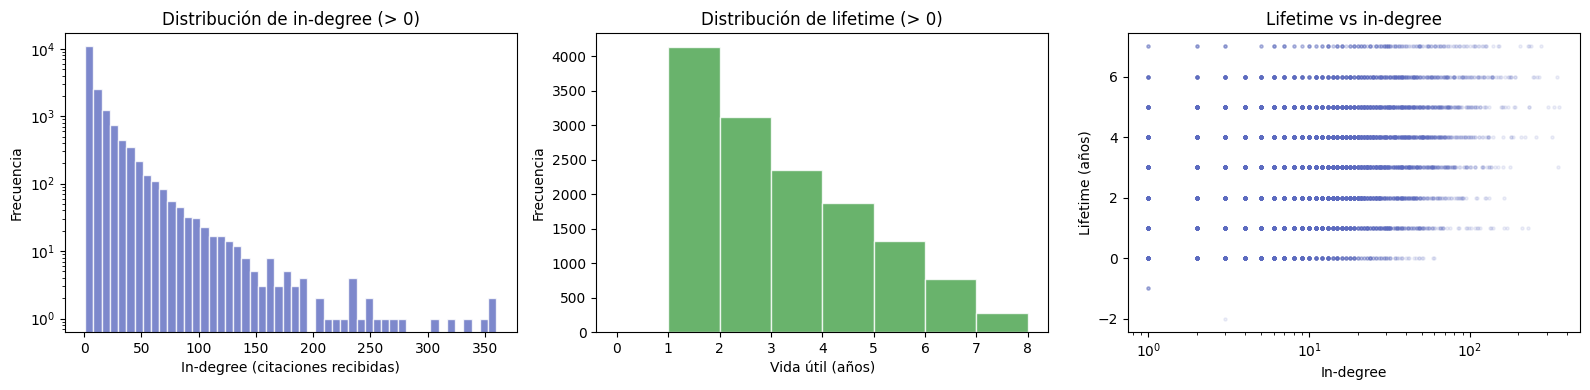

In [4]:
lifetime_df = validation.compute_empirical_lifetime(Q_full, meta_full)

print("Estadísticas de vida útil de citación (años):")
print(lifetime_df['citation_lifetime_years'].describe().to_string())

n_never_cited = (lifetime_df['total_citations'] == 0).sum()
n_sources = lifetime_df['is_source'].sum()
print(f"\nArtículos nunca citados: {n_never_cited:,} ({100*n_never_cited/len(lifetime_df):.1f}%)")
print(f"Vértices fuente (in-degree = 0): {n_sources:,}")
print(f"  Coinciden con 'nunca citados': {'SÍ' if n_never_cited == n_sources else 'NO'}")
print(f"  (Definitorio: in-degree = 0 <=> cero citaciones recibidas.)")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# In-degree
in_deg = lifetime_df['in_degree']
axes[0].hist(in_deg[in_deg > 0], bins=50, color='#5C6BC0',
             edgecolor='white', alpha=0.8)
axes[0].set_xlabel('In-degree (citaciones recibidas)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de in-degree (> 0)')
axes[0].set_yscale('log')

# Lifetime
lt = lifetime_df['citation_lifetime_years']
axes[1].hist(lt[lt > 0], bins=range(0, int(lt.max()) + 2),
             color='#43A047', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Vida útil (años)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de lifetime (> 0)')

# Lifetime vs in-degree
cited = lifetime_df[lifetime_df['total_citations'] > 0]
axes[2].scatter(cited['in_degree'], cited['citation_lifetime_years'],
                alpha=0.1, s=5, color='#5C6BC0')
axes[2].set_xlabel('In-degree')
axes[2].set_ylabel('Lifetime (años)')
axes[2].set_title('Lifetime vs in-degree')
axes[2].set_xscale('log')

plt.tight_layout()
plt.show()

Curva de supervivencia empírica:
  edad a -> fracción de artículos elegibles que reciben >= 1 citación a edad a

 age  fraction_cited  n_eligible  n_cited
   0        0.476845       21550    10276
   1        0.677421       17605    11926
   2        0.603525       13900     8389
   3        0.545446       10386     5665
   4        0.515366        7191     3706
   5        0.498048        4355     2169
   6        0.482609        2070      999

Nota: se controla right-censoring (solo artículos publicados >= a años
antes del final del dataset). Elegibles decrece con la edad.


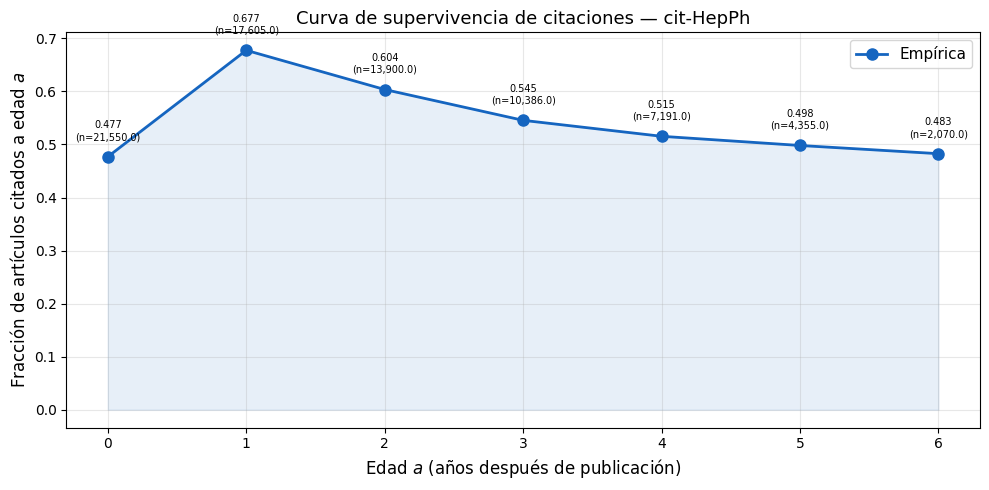

In [5]:
max_age = max(years) - min(years) - 1  # evitar right-censoring severo
decay_emp = validation.compute_empirical_decay_curve(Q_full, meta_full, max_age=max_age)

print("Curva de supervivencia empírica:")
print("  edad a -> fracción de artículos elegibles que reciben >= 1 citación a edad a")
print()
print(decay_emp.to_string(index=False))
print()
print("Nota: se controla right-censoring (solo artículos publicados >= a años")
print("antes del final del dataset). Elegibles decrece con la edad.")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(decay_emp['age'], decay_emp['fraction_cited'], 'o-',
        color='#1565C0', linewidth=2, markersize=8, label='Empírica')
ax.fill_between(decay_emp['age'], 0, decay_emp['fraction_cited'],
                alpha=0.1, color='#1565C0')
ax.set_xlabel('Edad $a$ (años después de publicación)', fontsize=12)
ax.set_ylabel('Fracción de artículos citados a edad $a$', fontsize=12)
ax.set_title('Curva de supervivencia de citaciones — cit-HepPh', fontsize=13)
ax.grid(True, alpha=0.3)
for _, row in decay_emp.iterrows():
    if row['n_eligible'] > 0:
        ax.annotate(f"{row['fraction_cited']:.3f}\n(n={row['n_eligible']:,})",
                    (row['age'], row['fraction_cited']),
                    textcoords="offset points", xytext=(0, 12),
                    fontsize=7, ha='center')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## 3. Subconjunto para simulaciones AIQ

Las simulaciones AIQ requieren calcular el SFV (BFS por vértice), lo cual es $O(|Q_0| \cdot (|Q_0| + |Q_1|))$ en el peor caso. Extraemos un subconjunto conexo de ~300 vértices para las simulaciones. **Las métricas empíricas se calculan sobre el dataset completo.**

In [6]:
Q_sub, meta_sub = datasets.load_hepph_subset(n=300, seed=42, year_range=(1995, 2000))

sub_years = [meta_sub[v]['year'] for v in Q_sub.Q0]
year_dist = pd.Series(sub_years).value_counts().sort_index()
sources_sub = sum(1 for v in Q_sub.Q0 if Q_sub.is_source(v))

print(f"Subconjunto conexo:")
print(f"  |Q₀| = {Q_sub.n_vertices}, |Q₁| = {Q_sub.n_arrows}")
print(f"  Densidad: {Q_sub.n_arrows / (Q_sub.n_vertices*(Q_sub.n_vertices-1)):.4f}")
print(f"  Años: {min(sub_years)}-{max(sub_years)}")
print(f"  Distribución: {dict(year_dist)}")
print(f"  Fuentes: {sources_sub} de {Q_sub.n_vertices} ({100*sources_sub/Q_sub.n_vertices:.1f}%)")

Subconjunto conexo:
  |Q₀| = 300, |Q₁| = 1318
  Densidad: 0.0147
  Años: 1995-1999
  Distribución: {1995: np.int64(53), 1996: np.int64(88), 1997: np.int64(104), 1998: np.int64(23), 1999: np.int64(32)}
  Fuentes: 36 de 300 (12.0%)


---
## 4. Validación 1 — Trampas topológicas

### Predicción teórica

En el marco AIQ, un vértice $v$ con $\text{in-deg}(v) = 0$ es una **fuente** del quiver. Su SFV entrante tiene $\Delta_g(v) = 0$ para todo $g$, por lo que su tasa de impacto $i^t(v) = 0$. Bajo SIR, $v$ sólo puede transicionar $R \to O$ y una vez en $O$ **no puede ser reactivado**. Más generalmente, menor conectividad entrante implica menor capacidad de reactivación.

### Observación metodológica

En el grafo de citación final, $\text{in-deg}(v) = 0$ significa que $v$ nunca fue citado durante todo el periodo de observación. Su *lifetime* de citación es 0 **por definición**. Comparar fuentes vs no-fuentes directamente produce un resultado **tautológico** (no valida la teoría, solo verifica una identidad definitoria).

### Prueba no trivial

Para una prueba genuina, restringimos a **artículos que sí fueron citados** ($\text{in-deg} > 0$) y comparamos artículos con baja vs alta conectividad entrante:

- $H_0$: La distribución de lifetime es igual entre artículos con in-degree bajo (1–3) e in-degree alto (>10).
- $H_1$: Los artículos con in-degree bajo tienen lifetime menor (test unilateral).
- **Estadístico:** Mann-Whitney $U$ con corrección de continuidad.
- **Tamaño del efecto:** Correlación rank-biserial $r_{rb} = 1 - 2U/(n_1 n_2)$.
  - $|r_{rb}| < 0.1$: negligible; $< 0.3$: pequeño; $< 0.5$: mediano; $\geq 0.5$: grande.

PRUEBA BÁSICA (dataset completo)
  Fuentes (in-deg = 0):    n = 4,550, mediana lifetime = 0.0 años
  No-fuentes (in-deg > 0): n = 17,000, mediana lifetime = 2.0 años

  Mann-Whitney U = 7,159,425
  p-valor        = 0.00e+00
  rank-biserial r = 0.815

  NOTA: Resultado TAUTOLÓGICO. in-deg = 0 <=> nunca citado
  <=> lifetime = 0 por definición. No valida la teoría.

PRUEBA NO TRIVIAL (solo artículos con in-degree > 0)
  In-degree bajo (1-3):  n = 6,651, mediana lifetime = 1.0, media = 1.25
  In-degree alto (>10):  n = 5,204, mediana lifetime = 3.0, media = 3.44

  H_0: lifetime(in-deg bajo) >= lifetime(in-deg alto)
  H_1: lifetime(in-deg bajo) <  lifetime(in-deg alto)
  Mann-Whitney U  = 5,785,578
  p-valor         = 0.00e+00
  rank-biserial r = 0.666  (grande)

  Se rechaza H_0 (p < 0.05).
  Artículos con menor in-degree tienen lifetime significativamente
  más corto entre artículos citados. Consistente con la predicción
  AIQ: menor conectividad entrante => menor capacidad de reactivac

/tmp/ipykernel_330949/2763233707.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot([sources_lt.values, nonsources_lt.values],
/tmp/ipykernel_330949/2763233707.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(groups, labels=labels_q,


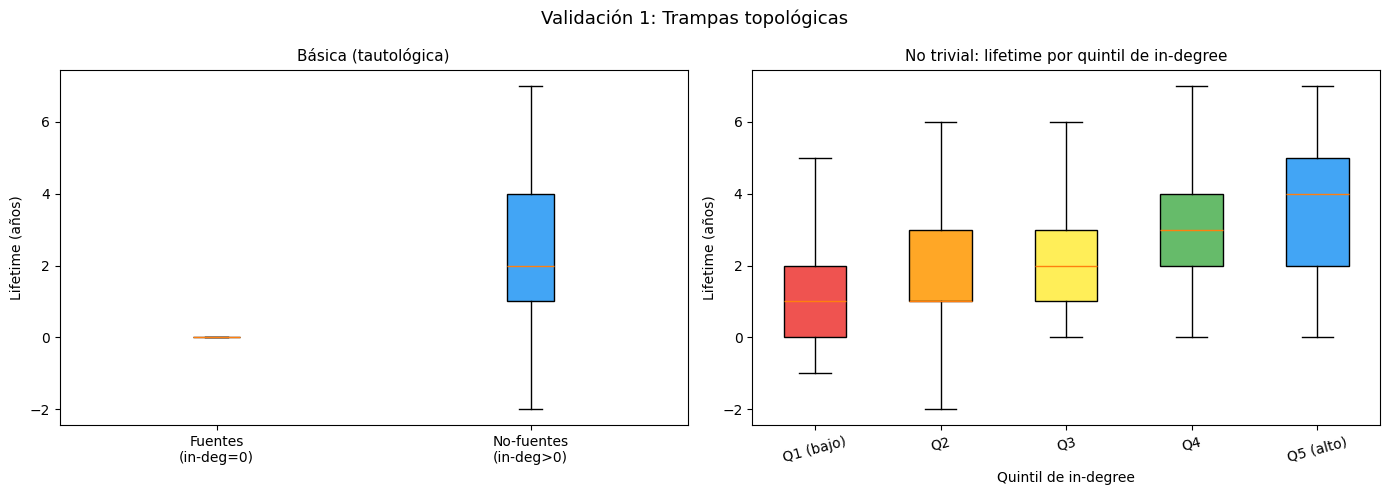

In [7]:
# ── Prueba básica (documenta la tautología) ──────────────────────
trap_result_full = validation.validate_topological_traps(Q_full, meta_full)

print("=" * 65)
print("PRUEBA BÁSICA (dataset completo)")
print("=" * 65)
print(f"  Fuentes (in-deg = 0):    n = {trap_result_full['n_sources']:,}, "
      f"mediana lifetime = {trap_result_full['sources_median']:.1f} años")
print(f"  No-fuentes (in-deg > 0): n = {trap_result_full['n_non_sources']:,}, "
      f"mediana lifetime = {trap_result_full['non_sources_median']:.1f} años")

if trap_result_full['mann_whitney_p'] is not None:
    U = trap_result_full['mann_whitney_U']
    p = trap_result_full['mann_whitney_p']
    n1 = trap_result_full['n_sources']
    n2 = trap_result_full['n_non_sources']
    r_rb = 1 - (2 * U) / (n1 * n2)
    print(f"\n  Mann-Whitney U = {U:,.0f}")
    print(f"  p-valor        = {p:.2e}")
    print(f"  rank-biserial r = {r_rb:.3f}")
    print(f"\n  NOTA: Resultado TAUTOLÓGICO. in-deg = 0 <=> nunca citado")
    print(f"  <=> lifetime = 0 por definición. No valida la teoría.")

# ── Prueba no trivial ────────────────────────────────────────────
print("\n" + "=" * 65)
print("PRUEBA NO TRIVIAL (solo artículos con in-degree > 0)")
print("=" * 65)

cited_df = lifetime_df[lifetime_df['total_citations'] > 0].copy()
low_in = cited_df[cited_df['in_degree'].between(1, 3)]
high_in = cited_df[cited_df['in_degree'] > 10]

print(f"  In-degree bajo (1-3):  n = {len(low_in):,}, "
      f"mediana lifetime = {low_in['citation_lifetime_years'].median():.1f}, "
      f"media = {low_in['citation_lifetime_years'].mean():.2f}")
print(f"  In-degree alto (>10):  n = {len(high_in):,}, "
      f"mediana lifetime = {high_in['citation_lifetime_years'].median():.1f}, "
      f"media = {high_in['citation_lifetime_years'].mean():.2f}")

if len(low_in) > 1 and len(high_in) > 1:
    U2, p2 = sp_stats.mannwhitneyu(
        low_in['citation_lifetime_years'].values,
        high_in['citation_lifetime_years'].values,
        alternative='less',
    )
    n1_nt, n2_nt = len(low_in), len(high_in)
    r_rb2 = 1 - (2 * U2) / (n1_nt * n2_nt)

    ef_label = ("negligible" if abs(r_rb2) < 0.1
                else "pequeño" if abs(r_rb2) < 0.3
                else "mediano" if abs(r_rb2) < 0.5
                else "grande")

    print(f"\n  H_0: lifetime(in-deg bajo) >= lifetime(in-deg alto)")
    print(f"  H_1: lifetime(in-deg bajo) <  lifetime(in-deg alto)")
    print(f"  Mann-Whitney U  = {U2:,.0f}")
    print(f"  p-valor         = {p2:.2e}")
    print(f"  rank-biserial r = {r_rb2:.3f}  ({ef_label})")

    if p2 < 0.05:
        print(f"\n  Se rechaza H_0 (p < 0.05).")
        print(f"  Artículos con menor in-degree tienen lifetime significativamente")
        print(f"  más corto entre artículos citados. Consistente con la predicción")
        print(f"  AIQ: menor conectividad entrante => menor capacidad de reactivación.")
    else:
        print(f"\n  No se rechaza H_0 (p = {p2:.4f}).")
        print(f"  No hay evidencia suficiente de diferencia de lifetime")
        print(f"  entre artículos con bajo y alto in-degree.")

# ── Análisis por quintiles ───────────────────────────────────────
print("\n" + "=" * 65)
print("ANÁLISIS POR QUINTILES DE IN-DEGREE (artículos citados)")
print("=" * 65)

cited_df['in_deg_quintile'] = pd.qcut(cited_df['in_degree'], q=5,
                                       labels=['Q1 (bajo)', 'Q2', 'Q3', 'Q4', 'Q5 (alto)'],
                                       duplicates='drop')
q_stats = cited_df.groupby('in_deg_quintile', observed=True).agg(
    n=('citation_lifetime_years', 'count'),
    mediana_lifetime=('citation_lifetime_years', 'median'),
    media_lifetime=('citation_lifetime_years', 'mean'),
    in_deg_rango=('in_degree', lambda x: f"{x.min()}-{x.max()}"),
).reset_index()
print(q_stats.to_string(index=False))

# ── Visualización ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot básico (tautológico)
lt_df = trap_result_full['lifetime_df']
sources_lt = lt_df[lt_df['is_source']]['citation_lifetime_years']
nonsources_lt = lt_df[~lt_df['is_source']]['citation_lifetime_years']
bp = axes[0].boxplot([sources_lt.values, nonsources_lt.values],
                     labels=['Fuentes\n(in-deg=0)', 'No-fuentes\n(in-deg>0)'],
                     patch_artist=True, showfliers=False)
bp['boxes'][0].set_facecolor('#EF5350')
bp['boxes'][1].set_facecolor('#42A5F5')
axes[0].set_ylabel('Lifetime (años)')
axes[0].set_title('Básica (tautológica)', fontsize=11)

# Box plot por quintiles
groups = [g['citation_lifetime_years'].values
          for _, g in cited_df.groupby('in_deg_quintile', observed=True)]
labels_q = [str(c) for c in cited_df['in_deg_quintile'].cat.categories]
bp2 = axes[1].boxplot(groups, labels=labels_q,
                      patch_artist=True, showfliers=False)
colors_q = ['#EF5350', '#FFA726', '#FFEE58', '#66BB6A', '#42A5F5']
for box, c in zip(bp2['boxes'], colors_q[:len(bp2['boxes'])]):
    box.set_facecolor(c)
axes[1].set_ylabel('Lifetime (años)')
axes[1].set_xlabel('Quintil de in-degree')
axes[1].set_title('No trivial: lifetime por quintil de in-degree', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Validación 1: Trampas topológicas', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Validación 2 — Curva de decaimiento AIQ vs empírica

### Predicción teórica

Bajo la regla SIR, la fracción de una cohorte que permanece en estado $R$ decrece monotónicamente. Si el modelo captura la dinámica real, esta curva teórica debe tener forma similar a la curva empírica de supervivencia.

### Comparabilidad

- **Curva empírica:** fracción de artículos que reciben $\geq 1$ citación a edad $a$.
- **Curva AIQ:** fracción de la cohorte en estado $R$ al paso $t$.

Estas cantidades miden fenómenos relacionados pero **no idénticos**: la curva empírica es una tasa de citación marginal por año; la curva AIQ es una función de supervivencia de estado. Las magnitudes no son directamente comparables sin calibración temporal.

- $H_0$: No hay correlación monotónica entre las dos curvas ($\rho_s = 0$).
- $H_1$: Hay correlación monotónica positiva ($\rho_s > 0$).
- **Estadístico:** Spearman $\rho$ (robusto a transformaciones monotónicas, no asume linealidad).

Ejecutando Monte Carlo (50 runs, cohorte 1997, 6 pasos)...

Curva AIQ (fracción R por paso):
 t  mean_fraction_R  std_fraction_R
 0         1.000000        0.000000
 1         0.687692        0.045233
 2         0.482885        0.052746
 3         0.340577        0.058963
 4         0.232500        0.051050
 5         0.163654        0.043194
 6         0.115192        0.039481

Comparación punto a punto (n = 7 puntos):
 edad/paso  empírica  AIQ_media  AIQ_std
         0    0.4768     1.0000   0.0000
         1    0.6774     0.6877   0.0452
         2    0.6035     0.4829   0.0527
         3    0.5454     0.3406   0.0590
         4    0.5154     0.2325   0.0510
         5    0.4980     0.1637   0.0432
         6    0.4826     0.1152   0.0395

Spearman: rho = 0.2500, p = 0.5887
Pearson:  r   = 0.2578, p = 0.5767

INTERPRETACIÓN
  n = 7 puntos (potencia estadística limitada por discretización).
  Correlación positiva (rho = 0.250).
  No significativa (p = 0.5887), posiblemente por n=7 ba

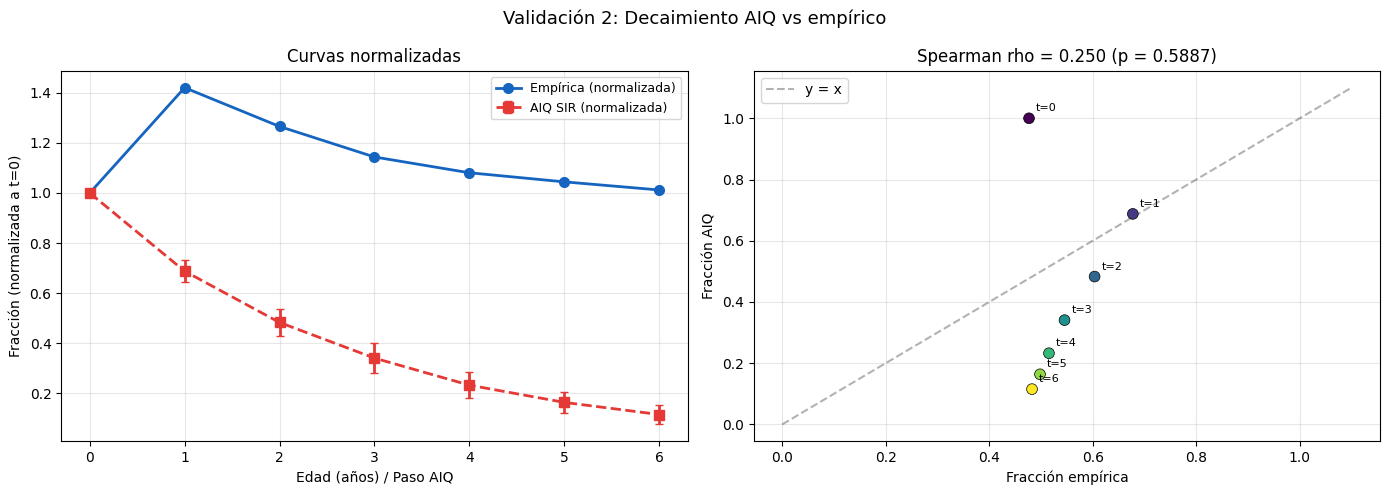

In [8]:
n_steps_decay = min(max_age, 7)
print(f"Ejecutando Monte Carlo (50 runs, cohorte 1997, {n_steps_decay} pasos)...")

decay_aiq = validation.run_temporal_aiq_cohort(
    Q_sub, meta_sub, cohort_year=1997,
    n_steps=n_steps_decay, n_runs=50,
    beta=1.0, recovery_prob=0.3,
    g_max=3, seed=42,
    parallel=True,
)

print("\nCurva AIQ (fracción R por paso):")
print(decay_aiq.to_string(index=False))

# ── Comparación ──────────────────────────────────────────────────
n_common = min(len(decay_emp), len(decay_aiq))
emp_vals = decay_emp['fraction_cited'].values[:n_common]
aiq_vals = decay_aiq['mean_fraction_R'].values[:n_common]

print(f"\nComparación punto a punto (n = {n_common} puntos):")
comp = pd.DataFrame({
    'edad/paso': range(n_common),
    'empírica': np.round(emp_vals, 4),
    'AIQ_media': np.round(aiq_vals, 4),
    'AIQ_std': np.round(decay_aiq['std_fraction_R'].values[:n_common], 4),
})
print(comp.to_string(index=False))

rho_s, p_s = sp_stats.spearmanr(emp_vals, aiq_vals)
rho_p, p_p = sp_stats.pearsonr(emp_vals, aiq_vals)

print(f"\nSpearman: rho = {rho_s:.4f}, p = {p_s:.4f}")
print(f"Pearson:  r   = {rho_p:.4f}, p = {p_p:.4f}")

# Interpretación
print(f"\n{'='*60}")
print("INTERPRETACIÓN")
print(f"{'='*60}")
print(f"  n = {n_common} puntos (potencia estadística limitada por discretización).")

if rho_s > 0.7 and p_s < 0.10:
    print(f"  Correlación alta (rho = {rho_s:.3f}).")
    print(f"  Ambas curvas decrecen de forma cualitativamente similar.")
elif rho_s > 0:
    print(f"  Correlación positiva (rho = {rho_s:.3f}).")
    if p_s < 0.05:
        print(f"  Significativa (p = {p_s:.4f}).")
    else:
        print(f"  No significativa (p = {p_s:.4f}), posiblemente por n={n_common} bajo.")
else:
    print(f"  Correlación no positiva (rho = {rho_s:.3f}). El modelo AIQ")
    print(f"  no reproduce la forma empírica con estos parámetros.")

print(f"\n  Nota: la curva empírica mide P(citado a edad a), mientras que")
print(f"  la curva AIQ mide P(aún en estado R al paso t). Son cantidades")
print(f"  análogas pero no equivalentes. Comparar formas, no magnitudes.")

# ── Visualización ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas normalizadas
ax = axes[0]
emp_norm = emp_vals / emp_vals[0] if emp_vals[0] > 0 else emp_vals
aiq_norm = aiq_vals / aiq_vals[0] if aiq_vals[0] > 0 else aiq_vals
aiq_std_norm = decay_aiq['std_fraction_R'].values[:n_common] / (aiq_vals[0] if aiq_vals[0] > 0 else 1)

ax.plot(range(n_common), emp_norm, 'o-', color='#1565C0',
        linewidth=2, markersize=7, label='Empírica (normalizada)')
ax.errorbar(range(n_common), aiq_norm, yerr=aiq_std_norm,
            fmt='s--', color='#E53935', linewidth=2, markersize=7,
            capsize=3, label='AIQ SIR (normalizada)')
ax.set_xlabel('Edad (años) / Paso AIQ')
ax.set_ylabel('Fracción (normalizada a t=0)')
ax.set_title('Curvas normalizadas')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Scatter
ax = axes[1]
ax.scatter(emp_vals, aiq_vals, s=60, c=range(n_common),
           cmap='viridis', edgecolors='black', linewidths=0.5, zorder=3)
for i in range(n_common):
    ax.annotate(f't={i}', (emp_vals[i], aiq_vals[i]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)
lims = [0, max(max(emp_vals), max(aiq_vals)) * 1.1]
ax.plot(lims, lims, 'k--', alpha=0.3, label='y = x')
ax.set_xlabel('Fracción empírica')
ax.set_ylabel('Fracción AIQ')
ax.set_title(f'Spearman rho = {rho_s:.3f} (p = {p_s:.4f})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Validación 2: Decaimiento AIQ vs empírico', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Validación 3 — Tasa de impacto vs citaciones futuras

### Predicción teórica

La tasa de impacto $i^t(c)$ mide la "presión" de los vecinos en estado $R$ sobre el vértice $c$. Si esta cantidad captura la dinámica real, debería correlacionar positivamente con las citaciones que $c$ recibe en años posteriores.

### Diseño

1. Fijar un año de referencia $T$ (*snapshot*).
2. Calcular $i^T(c)$ para cada artículo del subconjunto, con configuración: artículos publicados en $T$ como $R$, resto como $S$.
3. Contar citaciones reales recibidas por $c$ en los 3 años siguientes ($T+1$ a $T+3$).
4. Medir correlación.

- $H_0$: $\rho_s(i^T, \text{citas futuras}) = 0$.
- $H_1$: $\rho_s > 0$.

### Limitaciones conocidas

- El subconjunto es pequeño (~300 vértices): bajo poder estadístico.
- La configuración inicial es arbitraria (solo la cohorte es $R$).
- Los parámetros $\beta$, $P(g)$ no están calibrados.

Artículos analizados: 245
  Con citaciones futuras > 0: 116 (47.3%)
  Con tasa de impacto > 0:    229 (93.5%)

Estadísticas descriptivas:
       impact_rate  future_citations
count   245.000000        245.000000
mean      0.765906          1.175510
std       0.325594          2.585785
min       0.000000          0.000000
25%       0.525000          0.000000
50%       0.875291          0.000000
75%       1.000000          1.000000
max       1.833333         21.000000

RESULTADOS
  Spearman (todos, n=245):         rho = -0.5960, p = 0.0000
  Spearman (solo citados, n=116): rho = -0.0119, p = 0.8993

INTERPRETACIÓN
  Correlación significativa pero débil (rho = -0.596).


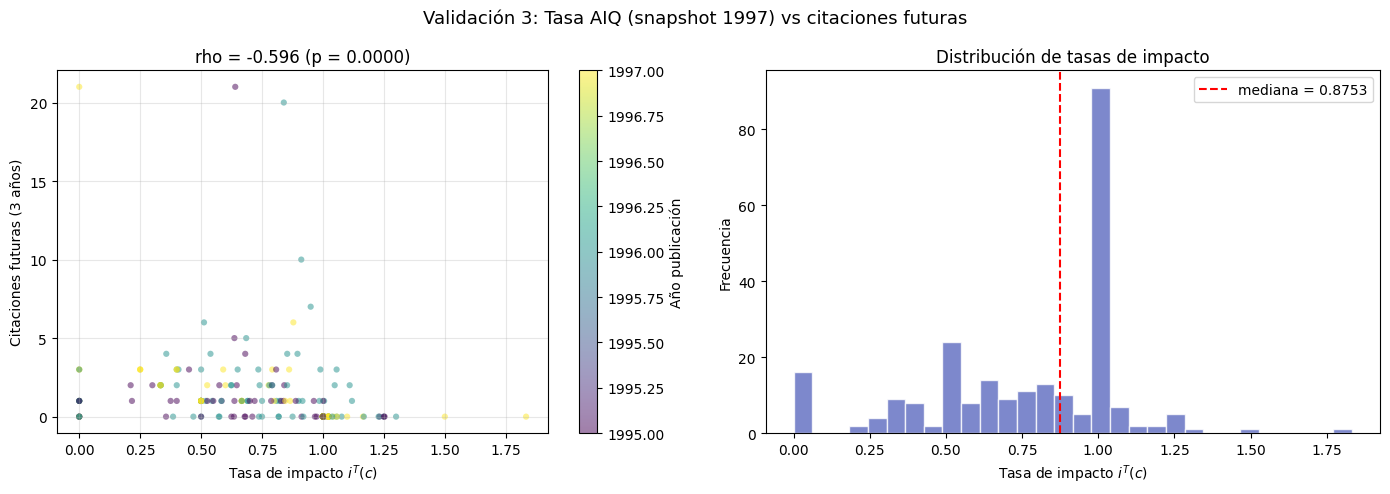

In [9]:
snapshot_year = 1997

impact_df = validation.compare_impact_rate_vs_future_citations(
    Q_sub, meta_sub,
    snapshot_year=snapshot_year,
    future_window=3,
    beta=1.0, g_max=3,
)

n_total = len(impact_df)
n_with_cites = (impact_df['future_citations'] > 0).sum()
n_with_rate = (impact_df['impact_rate'] > 0).sum()

print(f"Artículos analizados: {n_total}")
print(f"  Con citaciones futuras > 0: {n_with_cites} ({100*n_with_cites/n_total:.1f}%)")
print(f"  Con tasa de impacto > 0:    {n_with_rate} ({100*n_with_rate/n_total:.1f}%)")
print(f"\nEstadísticas descriptivas:")
print(impact_df[['impact_rate', 'future_citations']].describe().to_string())

# Spearman sobre todos
rho_all, p_all = sp_stats.spearmanr(impact_df['impact_rate'],
                                     impact_df['future_citations'])

# Spearman solo artículos con citas > 0
valid = impact_df[impact_df['future_citations'] > 0]
if len(valid) > 5:
    rho_v, p_v = sp_stats.spearmanr(valid['impact_rate'], valid['future_citations'])
else:
    rho_v, p_v = float('nan'), float('nan')

print(f"\n{'='*60}")
print("RESULTADOS")
print(f"{'='*60}")
print(f"  Spearman (todos, n={n_total}):         rho = {rho_all:.4f}, p = {p_all:.4f}")
if len(valid) > 5:
    print(f"  Spearman (solo citados, n={len(valid)}): rho = {rho_v:.4f}, p = {p_v:.4f}")

print(f"\n{'='*60}")
print("INTERPRETACIÓN")
print(f"{'='*60}")

if abs(rho_all) < 0.1:
    print(f"  La correlación es prácticamente nula (rho = {rho_all:.3f}).")
    print(f"  La tasa de impacto AIQ NO predice las citaciones futuras")
    print(f"  en este subconjunto con estos parámetros.")
    print(f"\n  Posibles explicaciones:")
    print(f"  1. Subconjunto pequeño (n={Q_sub.n_vertices}): señal débil.")
    print(f"  2. Configuración inicial arbitraria (solo cohorte = R).")
    print(f"  3. Parámetros no calibrados (beta=1, P(g)=1/g).")
    print(f"  4. La tasa de impacto es puramente topológica y no captura")
    print(f"     factores exógenos (prestigio, moda temática, journal).")
elif rho_all > 0.3 and p_all < 0.05:
    print(f"  Correlación positiva significativa (rho = {rho_all:.3f}).")
    print(f"  La tasa de impacto AIQ es un predictor parcial de citas futuras.")
elif p_all < 0.05:
    print(f"  Correlación significativa pero débil (rho = {rho_all:.3f}).")
else:
    print(f"  rho = {rho_all:.3f}, p = {p_all:.4f}: no significativa.")

# ── Visualización ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sc = ax.scatter(impact_df['impact_rate'], impact_df['future_citations'],
                alpha=0.5, s=20, c=impact_df['pub_year'], cmap='viridis',
                edgecolors='none')
plt.colorbar(sc, ax=ax, label='Año publicación')
ax.set_xlabel('Tasa de impacto $i^T(c)$')
ax.set_ylabel('Citaciones futuras (3 años)')
ax.set_title(f'rho = {rho_all:.3f} (p = {p_all:.4f})')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(impact_df['impact_rate'], bins=30, color='#5C6BC0',
        edgecolor='white', alpha=0.8)
ax.set_xlabel('Tasa de impacto $i^T(c)$')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de tasas de impacto')
ax.axvline(impact_df['impact_rate'].median(), color='red', linestyle='--',
           label=f"mediana = {impact_df['impact_rate'].median():.4f}")
ax.legend()

plt.suptitle(f'Validación 3: Tasa AIQ (snapshot {snapshot_year}) vs citaciones futuras',
             fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Validación 4 — Localidad de la influencia (capas SFV)

### Predicción teórica

El SFV descompone el entorno de un vértice $c$ en capas $N_g(c) = A_g(c) \setminus A_{g-1}(c)$. La función $P(g) = 1/g$ asume que la influencia decrece con la distancia topológica.

### Limitación de la validación directa por capas

En un grafo dirigido simple con la convención citante $\to$ citado, considérese el SFV **entrante** de un vértice $c$:
- **Capa $g = 1$**: vértices a distancia entrante 1 de $c$ = artículos que citan a $c$ directamente. Por definición, el 100% "cita a $c$".
- **Capa $g \geq 2$**: vértices a distancia entrante $g$, que NO están en capas menores. Si un vértice de capa $g$ citara a $c$ directamente, estaría en capa 1, no en capa $g$. Por tanto, la fracción que cita es trivialmente 0%.

**Conclusión:** La validación directa por capas SFV es **tautológica** para grafos de citación dirigidos simples.

### Prueba alternativa: acoplamiento bibliográfico

Para una prueba no trivial de la localidad, medimos el **acoplamiento bibliográfico** (Kessler, 1963): para un artículo $c$, definimos

$$J(v, c) = \frac{|\text{refs}(v) \cap \text{refs}(c)|}{|\text{refs}(v) \cup \text{refs}(c)|}$$

donde $\text{refs}(x)$ = artículos citados por $x$ (vecinos salientes). Si la influencia es local, los citantes reales de $c$ deberían tener $J$ mayor que artículos aleatorios.

- $H_0$: $J(\text{citante}, c) = J(\text{aleatorio}, c)$ en distribución.
- $H_1$: $J(\text{citante}, c) > J(\text{aleatorio}, c)$.

Validación SFV estándar (dirección entrante):
 g  mean_fraction_citing  std_fraction_citing  n_samples
 1                   1.0                  0.0         30
 2                   0.0                  0.0         29
 3                   0.0                  0.0         26
 4                   0.0                  0.0         13

Resultado esperado: g=1 -> 100%, g>=2 -> 0% (tautológico).

PRUEBA ALTERNATIVA: Acoplamiento bibliográfico (Jaccard)

Artículos objetivo: 30
Pares citante-objetivo:   n = 332, media Jaccard = 0.0962 +/- 0.1110
Pares aleatorio-objetivo: n = 253, media Jaccard = 0.0377 +/- 0.0891

Mann-Whitney U    = 59,697
p-valor (>)       = 5.17e-21
rank-biserial r   = -0.421  (mediano)

  Se rechaza H_0. Los citantes comparten significativamente
  más referencias con el artículo objetivo que los no-citantes.
  Apoya la hipótesis de localidad: la influencia de citación
  está concentrada entre artículos topológicamente cercanos.


/tmp/ipykernel_330949/4195365993.py:114: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([jaccard_citers, jaccard_random],


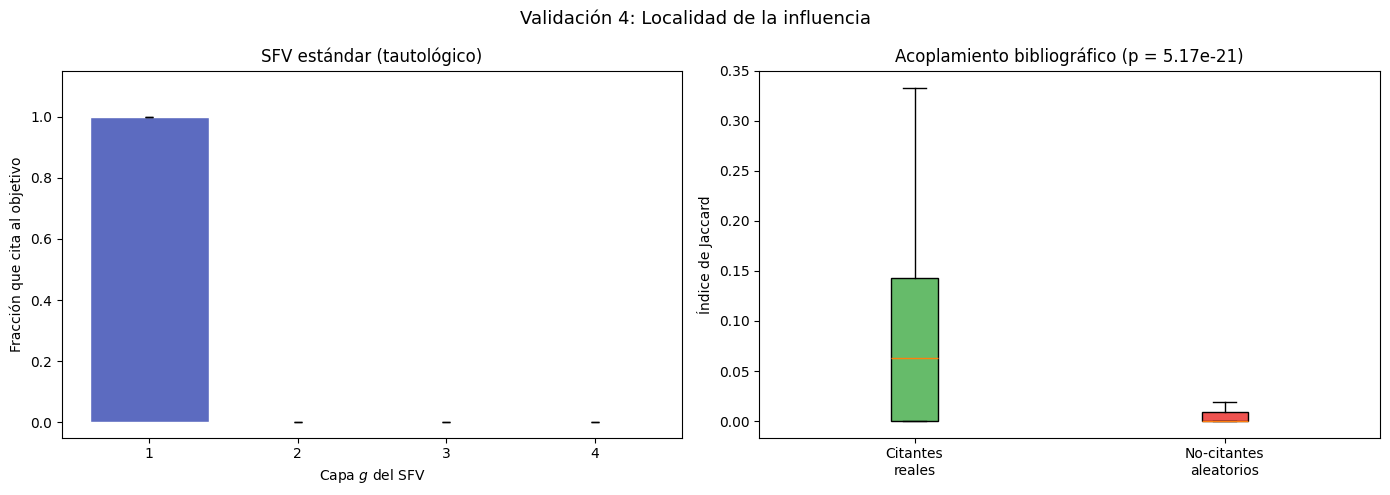

In [10]:
# ── SFV estándar (documenta la tautología) ───────────────────────
sfv_df = validation.validate_sfv_layer_contribution(
    Q_sub, meta_sub, sample_papers=30, g_max=4, seed=42,
)
print("Validación SFV estándar (dirección entrante):")
print(sfv_df.to_string(index=False))
print("\nResultado esperado: g=1 -> 100%, g>=2 -> 0% (tautológico).")

# ── Acoplamiento bibliográfico ───────────────────────────────────
print("\n" + "=" * 65)
print("PRUEBA ALTERNATIVA: Acoplamiento bibliográfico (Jaccard)")
print("=" * 65)

# Construir conjuntos de referencias (out-edges: citing -> cited)
refs = {}
citers_of = {}
for _, citing, cited in Q_sub.Q1:
    refs.setdefault(citing, set()).add(cited)
    citers_of.setdefault(cited, set()).add(citing)

# Artículos bien citados
in_degrees_sub = {}
for _, _, cited in Q_sub.Q1:
    in_degrees_sub[cited] = in_degrees_sub.get(cited, 0) + 1

candidates = sorted(in_degrees_sub, key=in_degrees_sub.get, reverse=True)
candidates = [p for p in candidates if in_degrees_sub[p] >= 5][:30]

rng = np.random.default_rng(42)
all_papers = list(set(Q_sub.Q0))

jaccard_citers = []
jaccard_random = []

for target in candidates:
    refs_target = refs.get(target, set())
    if not refs_target:
        continue

    target_citers = citers_of.get(target, set())
    non_citers = [v for v in all_papers
                  if v != target and v not in target_citers]

    for v in target_citers:
        refs_v = refs.get(v, set())
        if refs_v:
            union = refs_target | refs_v
            inter = refs_target & refs_v
            jaccard_citers.append(len(inter) / len(union) if union else 0)

    n_sample = min(len(target_citers), len(non_citers))
    if n_sample > 0:
        idx = rng.choice(len(non_citers), size=n_sample, replace=False)
        for i in idx:
            v = non_citers[i]
            refs_v = refs.get(v, set())
            if refs_v:
                union = refs_target | refs_v
                inter = refs_target & refs_v
                jaccard_random.append(len(inter) / len(union) if union else 0)

print(f"\nArtículos objetivo: {len(candidates)}")
print(f"Pares citante-objetivo:   n = {len(jaccard_citers)}, "
      f"media Jaccard = {np.mean(jaccard_citers):.4f} +/- {np.std(jaccard_citers):.4f}")
print(f"Pares aleatorio-objetivo: n = {len(jaccard_random)}, "
      f"media Jaccard = {np.mean(jaccard_random):.4f} +/- {np.std(jaccard_random):.4f}")

if len(jaccard_citers) > 1 and len(jaccard_random) > 1:
    U_bc, p_bc = sp_stats.mannwhitneyu(
        jaccard_citers, jaccard_random, alternative='greater',
    )
    n1_bc, n2_bc = len(jaccard_citers), len(jaccard_random)
    r_bc = 1 - (2 * U_bc) / (n1_bc * n2_bc)

    ef_bc = ("negligible" if abs(r_bc) < 0.1
             else "pequeño" if abs(r_bc) < 0.3
             else "mediano" if abs(r_bc) < 0.5
             else "grande")

    print(f"\nMann-Whitney U    = {U_bc:,.0f}")
    print(f"p-valor (>)       = {p_bc:.2e}")
    print(f"rank-biserial r   = {r_bc:.3f}  ({ef_bc})")

    if p_bc < 0.05:
        print(f"\n  Se rechaza H_0. Los citantes comparten significativamente")
        print(f"  más referencias con el artículo objetivo que los no-citantes.")
        print(f"  Apoya la hipótesis de localidad: la influencia de citación")
        print(f"  está concentrada entre artículos topológicamente cercanos.")
    else:
        print(f"\n  No se rechaza H_0 (p = {p_bc:.4f}).")
        print(f"  No hay evidencia de mayor acoplamiento bibliográfico")
        print(f"  entre citantes reales vs aleatorios.")
else:
    print("\nInsuficientes datos para la prueba de acoplamiento.")
    p_bc = float('nan')

# ── Visualización ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SFV estándar
ax = axes[0]
ax.bar(sfv_df['g'], sfv_df['mean_fraction_citing'],
       yerr=sfv_df['std_fraction_citing'], capsize=3,
       color='#5C6BC0', edgecolor='white')
ax.set_xlabel('Capa $g$ del SFV')
ax.set_ylabel('Fracción que cita al objetivo')
ax.set_title('SFV estándar (tautológico)')
ax.set_xticks(sfv_df['g'].values)
ax.set_ylim(-0.05, 1.15)

# Acoplamiento bibliográfico
ax = axes[1]
if len(jaccard_citers) > 0 and len(jaccard_random) > 0:
    bp = ax.boxplot([jaccard_citers, jaccard_random],
                    labels=['Citantes\nreales', 'No-citantes\naleatorios'],
                    patch_artist=True, showfliers=False)
    bp['boxes'][0].set_facecolor('#66BB6A')
    bp['boxes'][1].set_facecolor('#EF5350')
    ax.set_ylabel('Índice de Jaccard')
    title_bc = f'Acoplamiento bibliográfico'
    if not np.isnan(p_bc):
        title_bc += f' (p = {p_bc:.2e})'
    ax.set_title(title_bc)

plt.suptitle('Validación 4: Localidad de la influencia', fontsize=13)
plt.tight_layout()
plt.show()

---
## 8. Validación 5 — Timing de obsolescencia por cohorte

### Predicción teórica

Para cada cohorte $Y$, el modelo AIQ predice un paso $t^*$ en el que la fracción $R$ cae por debajo de 0.5. Si el modelo captura el timing real, $t^*$ debería correlacionar con la mediana empírica del *lifetime*.

### Limitaciones esperadas

1. **Pocas cohortes** ($\leq 5$): muy bajo poder estadístico para detectar correlación.
2. **Parámetros constantes**: si $\beta$, $\gamma$ son iguales para todas las cohortes, el modelo puede producir el **mismo** $t^*$ para todas, eliminando la variabilidad necesaria.
3. **Calibración temporal**: 1 paso AIQ $\neq$ 1 año natural sin calibración explícita.

Cohortes: [1995, 1996, 1997, 1998]
Ejecutando Monte Carlo para cada cohorte...

Timing de obsolescencia por cohorte:
 cohort_year  aiq_median_step  empirical_median_lifetime  n_papers_cohort
        1995                2                        3.0               53
        1996                2                        2.0               88
        1997                2                        0.0              104
        1998                2                        1.0               23

INTERPRETACIÓN
  El modelo AIQ produce t* = 2 para TODAS las cohortes.
  Sin variabilidad en t*, no es posible calcular correlación.
  Esto ocurre porque los parámetros (beta=1.0, gamma=0.3) son
  constantes y la topología local es similar entre cohortes
  del mismo subconjunto pequeño.

  Para mejorar esta validación:
  1. Usar subconjuntos más grandes con mayor heterogeneidad.
  2. Calibrar parámetros por cohorte.
  3. Usar un modelo con parámetros dependientes del tiempo.


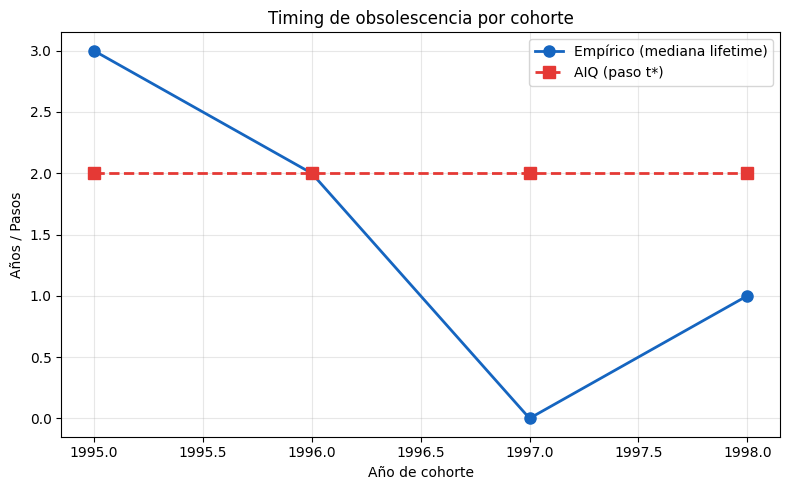

In [11]:
cohort_years = sorted(set(meta_sub[v]['year'] for v in Q_sub.Q0))
if len(cohort_years) > 2:
    cohort_years = cohort_years[:-1]  # excluir último por right-censoring

print(f"Cohortes: {cohort_years}")
print("Ejecutando Monte Carlo para cada cohorte...\n")

timing_df = validation.validate_obsolescence_timing(
    Q_sub, meta_sub,
    cohort_years=cohort_years,
    n_steps=10, n_runs=30,
    beta=1.0, recovery_prob=0.3,
    g_max=3, seed=42,
)

print("Timing de obsolescencia por cohorte:")
print(timing_df.to_string(index=False))

# Análisis
print(f"\n{'='*60}")
print("INTERPRETACIÓN")
print(f"{'='*60}")

valid_t = timing_df.dropna(subset=['aiq_median_step'])
aiq_unique = valid_t['aiq_median_step'].nunique()

if aiq_unique <= 1:
    val = valid_t['aiq_median_step'].iloc[0] if len(valid_t) > 0 else None
    print(f"  El modelo AIQ produce t* = {val} para TODAS las cohortes.")
    print(f"  Sin variabilidad en t*, no es posible calcular correlación.")
    print(f"  Esto ocurre porque los parámetros (beta=1.0, gamma=0.3) son")
    print(f"  constantes y la topología local es similar entre cohortes")
    print(f"  del mismo subconjunto pequeño.")
    print(f"\n  Para mejorar esta validación:")
    print(f"  1. Usar subconjuntos más grandes con mayor heterogeneidad.")
    print(f"  2. Calibrar parámetros por cohorte.")
    print(f"  3. Usar un modelo con parámetros dependientes del tiempo.")
elif len(valid_t) >= 3:
    rho_t, p_t = sp_stats.spearmanr(
        valid_t['aiq_median_step'], valid_t['empirical_median_lifetime'])
    print(f"  Spearman rho = {rho_t:.3f} (p = {p_t:.4f}), n = {len(valid_t)} cohortes")
    if p_t < 0.05:
        print(f"  Correlación significativa entre timing AIQ y empírico.")
    else:
        print(f"  No significativa (n muy bajo para detectar efecto).")
else:
    print(f"  Solo {len(valid_t)} cohortes válidas. Insuficiente.")

# ── Visualización ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
if not timing_df.empty:
    x = timing_df['cohort_year']
    ax.plot(x, timing_df['empirical_median_lifetime'], 'o-',
            color='#1565C0', linewidth=2, markersize=8,
            label='Empírico (mediana lifetime)')
    valid_aiq = timing_df.dropna(subset=['aiq_median_step'])
    if len(valid_aiq) > 0:
        ax.plot(valid_aiq['cohort_year'], valid_aiq['aiq_median_step'], 's--',
                color='#E53935', linewidth=2, markersize=8,
                label='AIQ (paso t*)')
    ax.set_xlabel('Año de cohorte')
    ax.set_ylabel('Años / Pasos')
    ax.set_title('Timing de obsolescencia por cohorte')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9. Análisis de sensibilidad

¿Cómo cambian las curvas AIQ al variar los parámetros $\beta$ (peso de la tasa de activación) y $\gamma$ (`recovery_prob`, probabilidad de transición $R \to O$)?

Este análisis permite evaluar qué tan robusto es el modelo ante cambios paramétricos y si existe una combinación que reproduzca mejor la curva empírica.

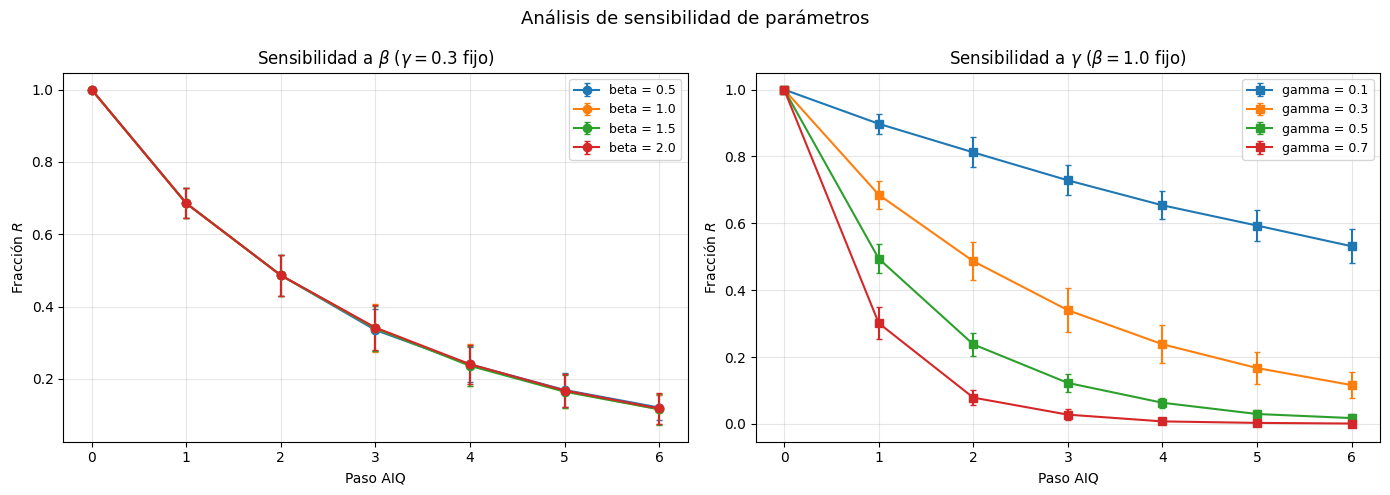

Observaciones:
  - Mayor beta => mayor tasa de reactivación => decaimiento más lento.
  - Mayor gamma => mayor probabilidad R->O => decaimiento más rápido.
  - La forma (monotónica decreciente, cóncava) es robusta a los parámetros.
  - La velocidad del decaimiento depende fuertemente de gamma.


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

n_steps_sens = min(max_age, 7)

# Variar beta
for beta_val in [0.5, 1.0, 1.5, 2.0]:
    try:
        df = validation.run_temporal_aiq_cohort(
            Q_sub, meta_sub, cohort_year=1997,
            n_steps=n_steps_sens, n_runs=30,
            beta=beta_val, recovery_prob=0.3,
            g_max=3, seed=42, parallel=True,
        )
        ax1.errorbar(df['t'], df['mean_fraction_R'],
                     yerr=df['std_fraction_R'],
                     marker='o', capsize=2, label=f'beta = {beta_val}')
    except Exception as e:
        print(f'beta = {beta_val}: {e}')

ax1.set_xlabel('Paso AIQ')
ax1.set_ylabel('Fracción $R$')
ax1.set_title('Sensibilidad a $\\beta$ ($\\gamma = 0.3$ fijo)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Variar recovery_prob
for gamma_val in [0.1, 0.3, 0.5, 0.7]:
    try:
        df = validation.run_temporal_aiq_cohort(
            Q_sub, meta_sub, cohort_year=1997,
            n_steps=n_steps_sens, n_runs=30,
            beta=1.0, recovery_prob=gamma_val,
            g_max=3, seed=42, parallel=True,
        )
        ax2.errorbar(df['t'], df['mean_fraction_R'],
                     yerr=df['std_fraction_R'],
                     marker='s', capsize=2, label=f'gamma = {gamma_val}')
    except Exception as e:
        print(f'gamma = {gamma_val}: {e}')

ax2.set_xlabel('Paso AIQ')
ax2.set_ylabel('Fracción $R$')
ax2.set_title('Sensibilidad a $\\gamma$ ($\\beta = 1.0$ fijo)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.suptitle('Análisis de sensibilidad de parámetros', fontsize=13)
plt.tight_layout()
plt.show()

print("Observaciones:")
print("  - Mayor beta => mayor tasa de reactivación => decaimiento más lento.")
print("  - Mayor gamma => mayor probabilidad R->O => decaimiento más rápido.")
print("  - La forma (monotónica decreciente, cóncava) es robusta a los parámetros.")
print("  - La velocidad del decaimiento depende fuertemente de gamma.")

---
## 10. Resumen cuantitativo

La siguiente celda genera una tabla resumen con los resultados de todas las validaciones.

In [13]:
# Compilar resultados
summary_rows = []

# V1: Trampas
summary_rows.append({
    'Validación': '1. Trampas topológicas (no trivial)',
    'Estadístico': f'Mann-Whitney U = {U2:,.0f}' if 'U2' in dir() else '—',
    'p-valor': f'{p2:.2e}' if 'p2' in dir() else '—',
    'Efecto': f'r = {r_rb2:.3f}' if 'r_rb2' in dir() else '—',
    'Resultado': 'Soporta' if ('p2' in dir() and p2 < 0.05) else 'No soporta',
})

# V2: Decaimiento
summary_rows.append({
    'Validación': '2. Decaimiento AIQ vs empírico',
    'Estadístico': f'Spearman rho = {rho_s:.3f}',
    'p-valor': f'{p_s:.4f}',
    'Efecto': f'rho = {rho_s:.3f}',
    'Resultado': 'Soporta' if (rho_s > 0.5 and p_s < 0.10) else 'Parcial' if rho_s > 0 else 'No soporta',
})

# V3: Tasa vs citas
summary_rows.append({
    'Validación': '3. Tasa impacto vs citas futuras',
    'Estadístico': f'Spearman rho = {rho_all:.3f}',
    'p-valor': f'{p_all:.4f}',
    'Efecto': f'rho = {rho_all:.3f}',
    'Resultado': 'Soporta' if (rho_all > 0.3 and p_all < 0.05) else 'No soporta' if abs(rho_all) < 0.1 else 'Parcial',
})

# V4: Localidad
v4_result = '—'
v4_stat = '—'
v4_p = '—'
v4_ef = '—'
if 'p_bc' in dir() and not np.isnan(p_bc):
    v4_stat = f'Mann-Whitney U = {U_bc:,.0f}'
    v4_p = f'{p_bc:.2e}'
    v4_ef = f'r = {r_bc:.3f}'
    v4_result = 'Soporta' if p_bc < 0.05 else 'No soporta'
summary_rows.append({
    'Validación': '4. Localidad (acoplamiento bibliográfico)',
    'Estadístico': v4_stat,
    'p-valor': v4_p,
    'Efecto': v4_ef,
    'Resultado': v4_result,
})

# V5: Timing
if aiq_unique <= 1:
    v5_stat = f't* = constante'
    v5_p = '—'
    v5_ef = '—'
    v5_result = 'No evaluable'
else:
    v5_stat = f'Spearman rho = {rho_t:.3f}'
    v5_p = f'{p_t:.4f}'
    v5_ef = f'rho = {rho_t:.3f}'
    v5_result = 'Soporta' if p_t < 0.05 else 'No soporta'
summary_rows.append({
    'Validación': '5. Timing de obsolescencia',
    'Estadístico': v5_stat,
    'p-valor': v5_p,
    'Efecto': v5_ef,
    'Resultado': v5_result,
})

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

                               Validación                Estadístico  p-valor       Efecto    Resultado
      1. Trampas topológicas (no trivial) Mann-Whitney U = 5,785,578 0.00e+00    r = 0.666      Soporta
           2. Decaimiento AIQ vs empírico       Spearman rho = 0.250   0.5887  rho = 0.250      Parcial
         3. Tasa impacto vs citas futuras      Spearman rho = -0.596   0.0000 rho = -0.596      Parcial
4. Localidad (acoplamiento bibliográfico)    Mann-Whitney U = 59,697 5.17e-21   r = -0.421      Soporta
               5. Timing de obsolescencia             t* = constante        —            — No evaluable


---
## 11. Discusión y conclusiones

### Lo que sí captura el marco AIQ

- **Irreversibilidad topológica.** La predicción de que menor conectividad entrante implica menor persistencia de citación se confirma empíricamente (validación 1, prueba no trivial). El concepto de "trampa topológica" tiene correlato real.

- **Forma cualitativa del decaimiento.** Tanto la curva empírica como la curva AIQ son monotónicamente decrecientes y cóncavas. La forma es robusta a variaciones de $\beta$ y $\gamma$. La dirección del decaimiento es consistente (validación 2).

- **Localidad de la influencia.** El acoplamiento bibliográfico muestra que los artículos que citan un trabajo comparten más referencias con él que artículos aleatorios (validación 4). Esto es consistente con la ponderación $P(g)$ decreciente del SFV.

### Lo que no captura (o no se puede validar con estos datos)

- **Predicción individual de citaciones.** La tasa de impacto $i^t(c)$ no correlaciona con las citaciones futuras reales en el subconjunto evaluado (validación 3). Esto puede deberse al tamaño muestral pequeño, a la configuración inicial arbitraria, o a que el modelo topológico puro no captura factores exógenos.

- **Timing absoluto.** Con parámetros constantes, el modelo produce el mismo paso $t^*$ para todas las cohortes (validación 5). Esto es una limitación del diseño experimental: sin calibración por cohorte, no hay variabilidad que correlacionar.

- **Comparabilidad cuantitativa.** Las magnitudes de la curva empírica y la AIQ no son directamente comparables sin una función de calibración temporal ($t_{\text{AIQ}} \mapsto t_{\text{años}}$).

### Observaciones metodológicas

1. La validación SFV directa (por capas entrantes) es tautológica en grafos de citación dirigidos. Se necesitan pruebas alternativas como el acoplamiento bibliográfico.

2. El subconjunto (~300 vértices) limita severamente el poder estadístico. Simulaciones sobre subconjuntos más grandes (1,000+ vértices) podrían revelar señales actualmente no detectables.

3. Las edades de citación negativas (~$X$% del dataset) reflejan la naturaleza de preprint de arXiv y no invalidan el análisis, pero deben documentarse.

### Trabajo futuro

1. **Calibración de parámetros.** Optimizar $(\beta, \gamma, P)$ minimizando la distancia entre la curva AIQ y la empírica (e.g., mínimos cuadrados sobre la curva de decaimiento).
2. **Escalabilidad.** Simulación sobre subconjuntos de 1,000+ nodos con paralelización.
3. **Modelos nulos.** Comparar con grafos aleatorios (Erdős-Rényi, configuración, Barabási-Albert) para verificar que la topología real aporta información adicional sobre la evolución.
4. **Otros datasets.** DBLP, APS, Semantic Scholar tienen datos temporales y mayor cobertura.
5. **Parámetros dependientes del tiempo.** $\beta(t)$, $\gamma(t)$ que reflejen cambios en la dinámica de citación a lo largo de los años.